## 感知器

> 本笔记本是 [AI for Beginners Curricula](http://github.com/microsoft/ai-for-beginners) 的一部分。请访问该仓库以获取完整的学习资料。

正如我们所讨论的，感知器可以用来解决**二分类问题**，即将输入样本分类为两个类别——我们可以称它们为**正类**和**负类**。

首先，让我们导入一些必要的库。


In [2]:
import pylab
from matplotlib import gridspec
from sklearn.datasets import make_classification
import numpy as np
from ipywidgets import interact, interactive, fixed
import ipywidgets as widgets
import pickle
import os
import gzip

# pick the seed for reproducability - change it to explore the effects of random variations
np.random.seed(1)
import random

## 玩具问题

首先，让我们从一个玩具问题开始，这里我们有两个输入特征。例如，在医学领域，我们可能希望根据肿瘤的大小和年龄将其分类为良性或恶性。

我们将使用 SciKit Learn 库中的 `make_classification` 函数生成一个随机分类数据集：


In [3]:
n = 50
X, Y = make_classification(n_samples = n, n_features=2,#特征数
                           n_redundant=0, n_informative=2, flip_y=0)#n_informative表示的是对分类有用的特征
Y = Y*2-1 # convert initial 0/1 values into -1/1 #y是label
X = X.astype(np.float32); Y = Y.astype(np.int32) # features - float, label - int

# Split the dataset into training and test
train_x, test_x = np.split(X, [ n*8//10])#np 的split传入的是索引或索引数组
train_labels, test_labels = np.split(Y, [n*8//10])
print("Features:\n",train_x[0:4])
print("Labels:\n",train_labels[0:4])

Features:
 [[-1.7441838  -1.3952037 ]
 [ 2.5921783  -0.08124504]
 [ 0.9218062   0.91789985]
 [-0.8437018  -0.18738253]]
Labels:
 [-1 -1  1 -1]


让我们也绘制数据集：


C:\Users\huawei\AppData\Local\Temp\ipykernel_17556\4230685035.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


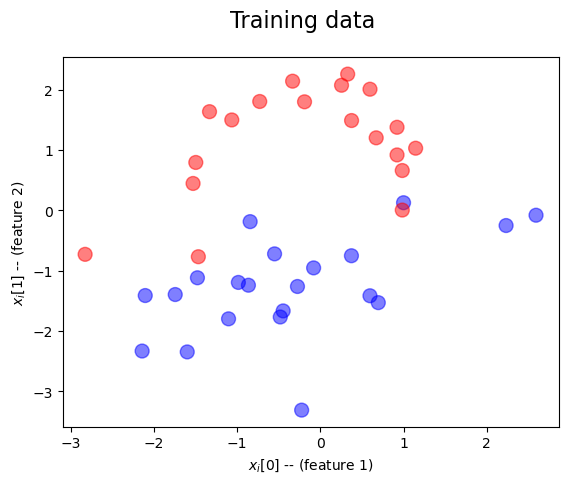

In [4]:
def plot_dataset(suptitle, features, labels):
    # prepare the plot
    fig, ax = pylab.subplots(1, 1)#只有一个子图，即不分割，fig相当于白纸，ax是作画空间
    #pylab.subplots_adjust(bottom=0.2, wspace=0.4)
    fig.suptitle(suptitle, fontsize = 16)#设置标题
    ax.set_xlabel('$x_i[0]$ -- (feature 1)')
    ax.set_ylabel('$x_i[1]$ -- (feature 2)')

    colors = ['r' if l>0 else 'b' for l in labels]
    ax.scatter(features[:, 0], features[:, 1], marker='o', c=colors, s=100, alpha = 0.5)
    fig.show()

plot_dataset('Training data', train_x, train_labels)

## 感知机

由于感知机是一个二分类器，对于每个输入向量 $x$，感知机的输出将根据类别为 +1 或 -1。输出通过以下公式计算：

$$y(\mathbf{x}) = f(\mathbf{w}^{\mathrm{T}}\mathbf{x})$$

其中，$\mathbf{w}$ 是权重向量，$f$ 是阶跃激活函数：
$$
f(x) = \begin{cases}
         +1 & x \geq 0 \\
         -1 & x < 0
       \end{cases} \\
$$

然而，一个通用的线性模型通常还需要一个偏置项，即理想情况下我们应该通过 $y=f(\mathbf{w}^{\mathrm{T}}\mathbf{x}+\mathbf{b})$ 来计算 $y$。为了简化我们的模型，我们可以通过在输入特征中添加一个始终等于 1 的维度来去掉这个偏置项：


In [5]:
pos_examples = np.array([ [t[0], t[1], 1] for i,t in enumerate(train_x) 
                          if train_labels[i]>0])
neg_examples = np.array([ [t[0], t[1], 1] for i,t in enumerate(train_x) 
                          if train_labels[i]<0])
print(pos_examples[0:3])

[[ 0.92180622  0.91789985  1.        ]
 [-1.06435513  1.49764717  1.        ]
 [ 0.32839951  2.25677919  1.        ]]


## 训练算法

为了训练感知机，我们需要找到能够最小化误差的权重 $\mathbf{w}$。误差通过**感知机准则**定义：

$$E(\mathbf{w}) = -\sum_{n \in \mathcal{M}}\mathbf{w}^{\mathrm{T}}\mathbf{x}_{n}t_{n}$$
 
  * $t_{n} \in \{-1, +1\}$ 分别表示负样本和正样本
  * $\mathcal{M}$ - 错误分类样本的集合
  
我们将使用**梯度下降**过程。从一些初始随机权重 $\mathbf{w}^{(0)}$ 开始，我们将在训练的每一步通过 $E$ 的梯度来调整权重：

$$\mathbf{w}^{\tau + 1}=\mathbf{w}^{\tau} - \eta \nabla E(\mathbf{w}) = \mathbf{w}^{\tau} + \eta\sum_{n \in \mathcal{M}}\mathbf{x}_{n} t_{n}$$

其中 $\eta$ 是**学习率**，$\tau\in\mathbb{N}$ 表示迭代次数。

我们用 Python 来定义这个算法：


In [6]:
def train(positive_examples, negative_examples, num_iterations = 100, learning_rate = 0.01):
    num_dims = positive_examples.shape[1]
    
    # Initialize weights. 
    # We initialize with 0 for simplicity, but random initialization is also a good idea
    weights = np.zeros((num_dims,1)) 
    
    pos_count = positive_examples.shape[0]
    neg_count = negative_examples.shape[0]
    
    report_frequency = 10
    
    for i in range(num_iterations):
        # Pick one positive and one negative example
        pos = random.choice(positive_examples)
        neg = random.choice(negative_examples)

        z = np.dot(pos, weights)   
        if z < 0: # positive example was classified as negative
            weights = weights + learning_rate * pos.reshape(weights.shape)

        z  = np.dot(neg, weights)
        if z >= 0: # negative example was classified as positive
            weights = weights - learning_rate * neg.reshape(weights.shape)
            
        # Periodically, print out the current accuracy on all examples 
        if i % report_frequency == 0:             
            pos_out = np.dot(positive_examples, weights)
            neg_out = np.dot(negative_examples, weights)        
            pos_correct = (pos_out >= 0).sum() / float(pos_count)
            neg_correct = (neg_out < 0).sum() / float(neg_count)
            print("Iteration={}, pos correct={}, neg correct={}".format(i,pos_correct,neg_correct))

    return weights

**关于学习率的说明**: `learning_rate` 参数（默认值为 `0.01`）控制我们在每次训练步骤中调整权重的幅度。这实现了梯度下降更新公式：

$$\mathbf{w}^{\tau + 1}=\mathbf{w}^{\tau} + \eta \mathbf{x}_{n} t_{n}$$

- 较大的学习率（例如 `1.0`）会使感知器学习速度更快，但可能会超出最优解
- 较小的学习率（例如 `0.001`）学习速度较慢，但可能更精确地收敛
- 你可以通过调用以下代码进行实验：`train(pos_examples, neg_examples, learning_rate=0.1)`


现在让我们在我们的数据集上运行训练：


In [7]:
# print(pos_examples)
wts = train(pos_examples,neg_examples)
print(wts.transpose())

Iteration=0, pos correct=0.6842105263157895, neg correct=0.8571428571428571
Iteration=10, pos correct=0.8947368421052632, neg correct=0.9047619047619048
Iteration=20, pos correct=0.7368421052631579, neg correct=1.0
Iteration=30, pos correct=0.9473684210526315, neg correct=0.7619047619047619
Iteration=40, pos correct=0.8947368421052632, neg correct=0.9523809523809523
Iteration=50, pos correct=0.8421052631578947, neg correct=0.9523809523809523
Iteration=60, pos correct=0.8947368421052632, neg correct=0.8571428571428571
Iteration=70, pos correct=0.8947368421052632, neg correct=0.9523809523809523
Iteration=80, pos correct=0.8947368421052632, neg correct=0.9523809523809523
Iteration=90, pos correct=0.8947368421052632, neg correct=0.9523809523809523
[[-0.02406236  0.04668178  0.01      ]]


如你所见，初始准确率大约为50%，但很快就提升到接近90%的较高值。

我们来可视化一下类别是如何分开的。我们的分类函数形式为 $\mathbf{w}^Tx$，对于一个类别，它的值大于0；对于另一个类别，它的值小于0。因此，类别分隔线由 $\mathbf{w}^Tx = 0$ 定义。由于我们只有两个维度 $x_0$ 和 $x_1$，这条线的方程可以写成 $w_0x_0+w_1x_1+w_2 = 0$（记住我们显式定义了一个额外维度 $x_2=1$）。现在我们来绘制这条线：


In [8]:
def plot_boundary(positive_examples, negative_examples, weights):
    if np.isclose(weights[1], 0):
        if np.isclose(weights[0], 0):
            x = y = np.array([-6, 6], dtype = 'float32')
        else:
            y = np.array([-6, 6], dtype='float32')
            x = -(weights[1] * y + weights[2])/weights[0]
    else:
        x = np.array([-6, 6], dtype='float32')
        y = -(weights[0] * x + weights[2])/weights[1]

    pylab.xlim(-6, 6)
    pylab.ylim(-6, 6)                      
    pylab.plot(positive_examples[:,0], positive_examples[:,1], 'bo')
    pylab.plot(negative_examples[:,0], negative_examples[:,1], 'ro')
    pylab.plot(x, y, 'g', linewidth=2.0)
    pylab.show()

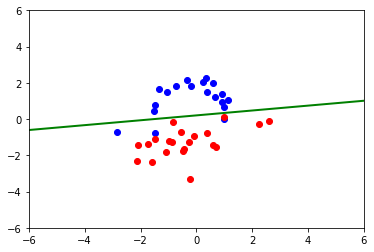

In [9]:
plot_boundary(pos_examples,neg_examples,wts)

## 探索学习率

现在让我们研究不同学习率如何影响训练过程。学习率控制梯度下降中的步长——这是一个关键的超参数，影响收敛速度和稳定性。


Iteration=0, pos correct=0.631578947368421, neg correct=0.8571428571428571
Iteration=10, pos correct=0.8421052631578947, neg correct=1.0
Iteration=20, pos correct=0.8421052631578947, neg correct=1.0
Iteration=30, pos correct=0.8421052631578947, neg correct=1.0
Iteration=40, pos correct=0.8421052631578947, neg correct=1.0
Iteration=50, pos correct=0.9473684210526315, neg correct=0.9523809523809523
Iteration=60, pos correct=0.8421052631578947, neg correct=0.9523809523809523
Iteration=70, pos correct=0.9473684210526315, neg correct=0.9523809523809523
Iteration=80, pos correct=0.9473684210526315, neg correct=0.9523809523809523
Iteration=90, pos correct=0.8947368421052632, neg correct=0.9523809523809523
Iteration=0, pos correct=0.7368421052631579, neg correct=0.9523809523809523
Iteration=10, pos correct=0.8947368421052632, neg correct=0.8571428571428571
Iteration=20, pos correct=1.0, neg correct=0.9047619047619048
Iteration=30, pos correct=0.8947368421052632, neg correct=0.9523809523809523


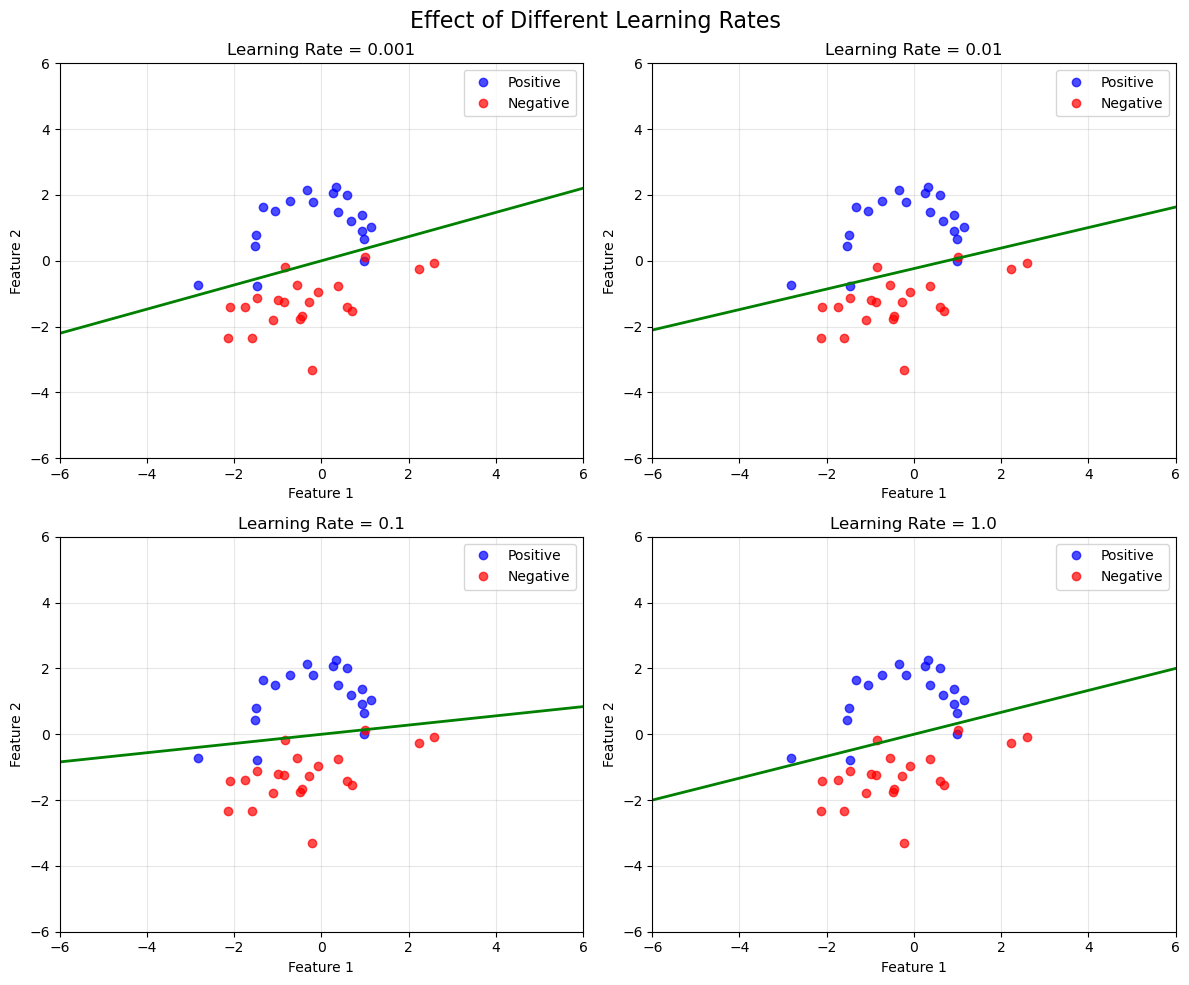

In [9]:
# Compare different learning rates
learning_rates = [0.001, 0.01, 0.1, 1.0]
fig, axes = pylab.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Effect of Different Learning Rates', fontsize=16)

for idx, lr in enumerate(learning_rates):
    ax = axes[idx // 2, idx % 2]
    
    # Train with this learning rate
    weights_lr = train(pos_examples, neg_examples, num_iterations=100, learning_rate=lr)
    
    # Plot decision boundary
    if np.isclose(weights_lr[1], 0):
        if np.isclose(weights_lr[0], 0):
            x = y = np.array([-6, 6], dtype='float32')
        else:
            y = np.array([-6, 6], dtype='float32')
            x = -(weights_lr[1] * y + weights_lr[2])/weights_lr[0]
    else:
        x = np.array([-6, 6], dtype='float32')
        y = -(weights_lr[0] * x + weights_lr[2])/weights_lr[1]
    
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.plot(pos_examples[:, 0], pos_examples[:, 1], 'bo', label='Positive', alpha=0.7)
    ax.plot(neg_examples[:, 0], neg_examples[:, 1], 'ro', label='Negative', alpha=0.7)
    ax.plot(x, y, 'g-', linewidth=2)
    ax.set_title(f'Learning Rate = {lr}')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend()
    ax.grid(True, alpha=0.3)

pylab.tight_layout()
pylab.show()


### 交互式学习率实验

使用下面的滑块，交互式地尝试不同的学习率，观察它们如何影响决策边界：


In [11]:
def train_and_plot_with_lr(learning_rate=0.01):
    """Train perceptron with specified learning rate and plot results"""
    weights_lr = train(pos_examples, neg_examples, num_iterations=100, learning_rate=learning_rate)
    
    fig, (ax1, ax2) = pylab.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Decision boundary
    if np.isclose(weights_lr[1], 0):
        if np.isclose(weights_lr[0], 0):
            x = y = np.array([-6, 6], dtype='float32')
        else:
            y = np.array([-6, 6], dtype='float32')
            x = -(weights_lr[1] * y + weights_lr[2])/weights_lr[0]
    else:
        x = np.array([-6, 6], dtype='float32')
        y = -(weights_lr[0] * x + weights_lr[2])/weights_lr[1]
    
    ax1.set_xlim(-6, 6)
    ax1.set_ylim(-6, 6)
    ax1.plot(pos_examples[:, 0], pos_examples[:, 1], 'bo', label='Positive', alpha=0.6)
    ax1.plot(neg_examples[:, 0], neg_examples[:, 1], 'ro', label='Negative', alpha=0.6)
    ax1.plot(x, y, 'g-', linewidth=3, label='Decision Boundary')
    ax1.set_title(f'Decision Boundary (lr={learning_rate})', fontsize=14)
    ax1.set_xlabel('Feature 1')
    ax1.set_ylabel('Feature 2')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Weight values
    ax2.bar(['w0', 'w1', 'bias'], weights_lr.flatten(), color=['blue', 'green', 'red'], alpha=0.7)
    ax2.set_title('Final Weight Values', fontsize=14)
    ax2.set_ylabel('Weight Value')
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    
    pylab.tight_layout()
    pylab.show()
    
    print(f"Final weights: {weights_lr.flatten()}")

# Create interactive widget
interact(train_and_plot_with_lr, 
         learning_rate=widgets.FloatSlider(value=0.01, min=0.001, max=1.0, step=0.001, 
                                          description='Learning Rate:', continuous_update=False))


interactive(children=(FloatSlider(value=0.01, continuous_update=False, description='Learning Rate:', max=1.0, …

<function __main__.train_and_plot_with_lr(learning_rate=0.01)>

## 在测试数据集上评估

一开始，我们将部分数据分离出来作为测试数据集。现在来看看我们的分类器在这个测试数据集上的准确性。为此，我们需要将测试数据集扩展一个额外的维度，与权重矩阵相乘，并确保得到的值与标签的符号一致（+1 或 -1）。然后将所有布尔值相加，并除以测试样本的长度，以计算准确率：


In [12]:
def accuracy(weights, test_x, test_labels):
    res = np.dot(np.c_[test_x,np.ones(len(test_x))],weights)
    return (res.reshape(test_labels.shape)*test_labels>=0).sum()/float(len(test_labels))

accuracy(wts, test_x, test_labels)

1.0

## 观察训练过程

我们之前已经看到，训练过程中准确率会下降。能够观察分割线在训练过程中的变化会很有趣。下面的代码将把所有内容可视化到一个图表上，你可以通过移动滑块来“时光穿梭”查看训练过程。


In [35]:
def train_graph(positive_examples, negative_examples, num_iterations = 100, learning_rate = 0.01):
    num_dims = positive_examples.shape[1]
    #positive_examples第0维为样本数，第二维为特征数
    weights = np.zeros((num_dims,1)) # initialize weights
    
    pos_count = positive_examples.shape[0]
    neg_count = negative_examples.shape[0]
    
    report_frequency = 15;
    snapshots = []
    
    for i in range(num_iterations):
        pos = random.choice(positive_examples)
        neg = random.choice(negative_examples)

        z = np.dot(pos, weights)   
        if z < 0:
            weights = weights + learning_rate * pos.reshape(weights.shape)

        z  = np.dot(neg, weights)
        if z >= 0:
            weights = weights - learning_rate * neg.reshape(weights.shape)
            
        if i % report_frequency == 0:             
            pos_out = np.dot(positive_examples, weights)
            neg_out = np.dot(negative_examples, weights)        
            pos_correct = (pos_out >= 0).sum() / float(pos_count)
            neg_correct = (neg_out < 0).sum() / float(neg_count)
            snapshots.append([np.copy(weights).flatten(), (pos_correct+neg_correct)/2.0])
            #添加权重和正确率

    return np.array(snapshots, dtype=object)

snapshots = train_graph(pos_examples,neg_examples)

def plotit(pos_examples,neg_examples,snapshots,step):
    fig = pylab.figure(figsize=(10,4))
    fig.add_subplot(1, 2, 1)
    plot_boundary(pos_examples, neg_examples, snapshots[step][0])
    fig.add_subplot(1, 2, 2)
    pylab.plot(np.arange(len(snapshots[:,1])), snapshots[:,1])
    pylab.ylabel('Accuracy')
    pylab.xlabel('Iteration')
    pylab.plot(step, snapshots[step,1], "bo")
    pylab.show()
def pl1(step): plotit(pos_examples,neg_examples,snapshots,step)

In [14]:
interact(pl1, step=widgets.IntSlider(value=0, min=0, max=len(snapshots)-1))

interactive(children=(IntSlider(value=0, description='step', max=6), Output()), _dom_classes=('widget-interact…

<function __main__.pl1(step)>

## 感知器的局限性

如上所述，感知器是一种**线性分类器**。如果两个类别是**线性可分的**，即可以用一条直线分开，那么感知器可以很好地区分它们。否则，感知器的训练过程将无法收敛。

一个最明显的例子是感知器无法解决的所谓**XOR问题**。我们希望感知器学习 XOR 布尔函数，其真值表如下：

|   | 0 | 1 |
|---|---|---|
| 0 | 0 | 1 | 
| 1 | 1 | 0 |

让我们试试吧！我们将手动填充所有正样本和负样本，然后调用我们上面定义的训练函数：


In [ ]:
pos_examples_xor = np.array([[1,0,1],[0,1,1]])#x1，x2不同，x3为偏置1
neg_examples_xor = np.array([[1,1,1],[0,0,1]])

snapshots_xor = train_graph(pos_examples_xor,neg_examples_xor,1000)
def pl2(step): plotit(pos_examples_xor,neg_examples_xor,snapshots_xor,step)

In [17]:
interact(pl2, step=widgets.IntSlider(value=0, min=0, max=len(snapshots)-1))

interactive(children=(IntSlider(value=0, description='step', max=6), Output()), _dom_classes=('widget-interact…

<function __main__.pl2(step)>

正如上图所示，准确率从未超过75%，因为不可能画出一条直线来正确分类所有可能的样本。

XOR问题是感知机局限性的经典例子，这一问题由Marvin Minsky和Seymour Papert在1969年他们的书籍[《感知机》](https://en.wikipedia.org/wiki/Perceptrons_(book))中指出。这一观察限制了神经网络领域的研究近10年，尽管——我们将在课程的下一部分看到——多层感知机完全能够解决此类问题。

## 复杂示例 - MNIST

尽管感知机无法解决XOR问题，但它可以解决许多更复杂的问题，例如手写字符识别。

一个常用于学习机器学习的数据集叫做[MNIST](https://en.wikipedia.org/wiki/MNIST_database)。该数据集由美国国家标准与技术研究院（Modified National Institute of Standards and Technology）创建，包含一个由60000个手写数字组成的训练集，这些数字来自研究院约250名学生和员工。此外，还有一个由10000个数字组成的测试集，这些数字来自不同的个人。

所有数字都以28x28像素的灰度图像表示。

> MNIST数据集在[Kaggle](https://www.kaggle.com/c/digit-recognizer)上作为一个训练竞赛提供。Kaggle是一个举办机器学习竞赛和比赛的网站。一旦你学会如何分类MNIST数字，可以将你的解决方案提交到Kaggle，看看它在其他参与者中的排名。

我们从加载MNIST数据集开始：


In [28]:
# If you are not running this notebook from a cloned repository, you may need to grab the binary dataset file first
# !wget https://github.com/microsoft/AI-For-Beginners/raw/main/data/mnist.pkl.gz?raw=true
# In this case correct the link to the dataset below as well.

with gzip.open('mnist.pkl.gz', 'rb') as mnist_pickle:
    mnist_tuple = pickle.load(mnist_pickle, encoding='latin1')

# 将元组转换为字典格式（匹配你原代码的键名）
MNIST = {
    'Train': {
        'Features': mnist_tuple[0][0],  # 训练集特征（X_train）
        'Labels': mnist_tuple[0][1]     # 训练集标签（y_train）
    },
    'Test': {
        'Features': mnist_tuple[1][0],  # 测试集特征（X_test）
        'Labels': mnist_tuple[1][1]     # 测试集标签（y_test）
    },
    'Validation': {  # 原数据集通常包含验证集，可选保留
        'Features': mnist_tuple[2][0],
        'Labels': mnist_tuple[2][1]
    }
}

现在我们来绘制数据集：


[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.01171875 0.0703125
 0.0703125  0.0703125  0.4921875  0.53125    0.68359375 0.1015625
 0.6484375  0.99609375 0.96484375 0.49609375 0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.1171875  0.140625
 0.3671875  0.6015625 ]
5


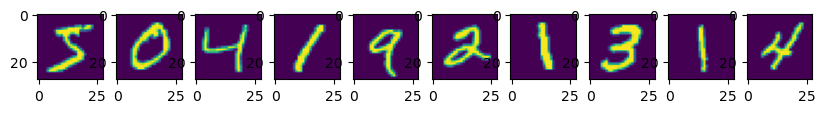

In [29]:
print(MNIST['Train']['Features'][0][130:180])
print(MNIST['Train']['Labels'][0])
features = MNIST['Train']['Features'].astype(np.float32) / 256.0
labels = MNIST['Train']['Labels']
fig = pylab.figure(figsize=(10,5))
for i in range(10):
    ax = fig.add_subplot(1,10,i+1)
    pylab.imshow(features[i].reshape(28,28))
pylab.show()

因为感知器是一个二分类器，我们将把问题限制为仅识别两个数字。下面的函数将用两个给定的数字填充正样本和负样本数组（并且还会显示这些数字的样本以便于理解）。


In [ ]:
def set_mnist_pos_neg(positive_label, negative_label):
    positive_indices = [i for i, j in enumerate(MNIST['Train']['Labels']) 
                          if j == positive_label]
    negative_indices = [i for i, j in enumerate(MNIST['Train']['Labels']) 
                          if j == negative_label]
    #获取正样本和负样本的索引

    positive_images = MNIST['Train']['Features'][positive_indices]
    negative_images = MNIST['Train']['Features'][negative_indices]
    #获取所有正样本"1"和负样本"0"的图像

    fig = pylab.figure()
    ax = fig.add_subplot(1, 2, 1)#分为一行2列，这是第一个子图
    pylab.imshow(positive_images[0].reshape(28,28), cmap='gray', interpolation='nearest')
    #只展现了一张
    ax.set_xticks([])
    ax.set_yticks([])
    ax = fig.add_subplot(1, 2, 2)
    pylab.imshow(negative_images[0].reshape(28,28), cmap='gray', interpolation='nearest')
    ax.set_xticks([])
    ax.set_yticks([])
    pylab.show()
    
    return positive_images, negative_images

我们将从尝试在0和1之间进行分类开始：


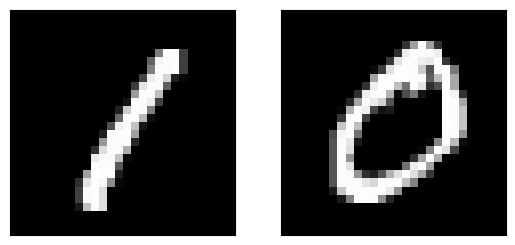

In [31]:
pos1,neg1 = set_mnist_pos_neg(1,0)

In [ ]:
def plotit2(snapshots_mn,step):
    fig = pylab.figure(figsize=(10,4))
    ax = fig.add_subplot(1, 2, 1)
    pylab.imshow(snapshots_mn[step][0].reshape(28, 28), interpolation='nearest')
    #画的是step步的权重图
    ax.set_xticks([])
    ax.set_yticks([])
    pylab.colorbar()
    ax = fig.add_subplot(1, 2, 2)
    ax.set_ylim([0,1])
    pylab.plot(np.arange(len(snapshots_mn[:,1])), snapshots_mn[:,1])
    pylab.plot(step, snapshots_mn[step,1], "bo")
    pylab.show()
def pl3(step): plotit2(snapshots_mn,step)
def pl4(step): plotit2(snapshots_mn2,step)    

In [ ]:
snapshots_mn = train_graph(pos1,neg1,1000)    
interact(pl3, step=widgets.IntSlider(value=0, min=0, max=len(snapshots_mn) - 1))

interactive(children=(IntSlider(value=0, description='step', max=66), Output()), _dom_classes=('widget-interac…

<function __main__.pl3(step)>

请注意，准确率会非常快地接近100%。

请将滑块移动到训练接近尾声的位置，并观察左侧绘制的权重矩阵。通过这个矩阵，你可以理解感知器的实际工作原理。你会看到在字段中间的权重值很高，这些对应于数字1通常出现的像素，而在两侧的权重值较低甚至为负，这些对应于数字0的部分。因此，如果呈现给感知器的数字确实是1，中间部分的像素会与高权重值相乘，产生正结果。相反，当感知器观察到数字0时，相应的像素会与负数相乘。

> 你可能会注意到，如果我们给感知器一个稍微水平偏移的数字1，使其像素占据了数字0的垂直部分位置，我们可能会得到错误的结果。这是因为我们的MNIST数据集的特点是所有数字都居中且位置正确，而感知器依赖这一点来区分数字。

现在让我们尝试不同的数字：


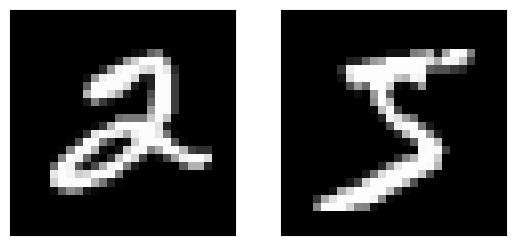

In [36]:
pos2,neg2 = set_mnist_pos_neg(2,5)

In [ ]:
snapshots_mn2 = train_graph(pos2,neg2,1000)
interact(pl4, step=widgets.IntSlider(value=0, min=0, max=len(snapshots_mn2) - 1))

interactive(children=(IntSlider(value=0, description='step', max=66), Output()), _dom_classes=('widget-interac…

<function __main__.pl4(step)>

## 讨论

由于某些原因，数字 2 和 5 并不容易区分。尽管我们获得了相对较高的准确率（超过 85%），但我们可以清楚地看到感知机在某个点停止了学习。

为了理解为什么会发生这种情况，我们可以尝试使用[主成分分析](https://en.wikipedia.org/wiki/Principal_component_analysis) (PCA)。这是一种机器学习技术，用于降低输入数据集的维度，以便在类之间获得最佳的可分性。

在我们的例子中，一张输入图像有 784 个像素（输入特征），我们希望使用 PCA 将参数数量减少到仅 2 个，这样我们就可以在图表上绘制它们。这两个参数将是原始特征的线性组合，我们可以将这一过程视为“旋转”我们原本的 784 维空间，并观察其在二维空间中的投影，直到我们获得能够最好地区分类别的视图为止。


In [38]:
from sklearn.decomposition import PCA

def pca_analysis(positive_label, negative_label):
    positive_images, negative_images = set_mnist_pos_neg(positive_label, negative_label)
    M = np.append(positive_images, negative_images, 0)

    mypca = PCA(n_components=2)
    mypca.fit(M)
    
    pos_points = mypca.transform(positive_images[:200])
    neg_points = mypca.transform(negative_images[:200])

    pylab.plot(pos_points[:,0], pos_points[:,1], 'bo')
    pylab.plot(neg_points[:,0], neg_points[:,1], 'ro')

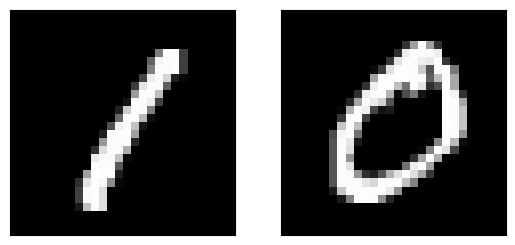

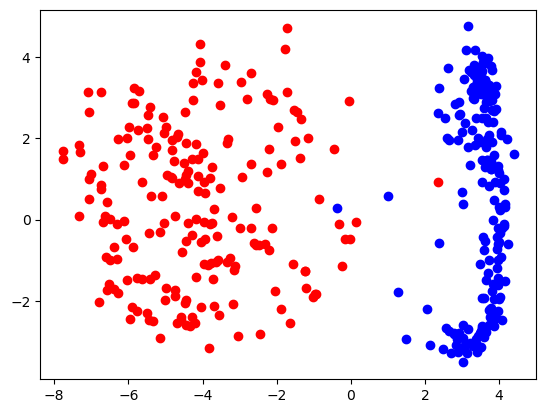

In [39]:
pca_analysis(1,0)

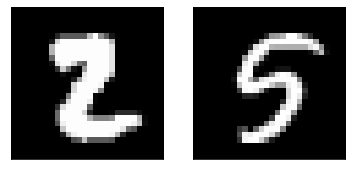

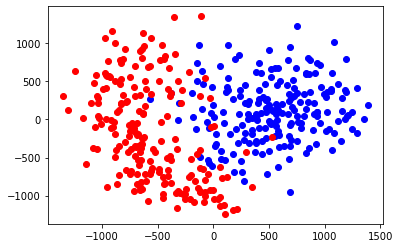

In [26]:
pca_analysis(2,5)

正如你所见，数字 0 和 1 可以通过一条直线清晰地分开。这表明在原始的 784 维空间中，与数字对应的点也是线性可分的。而对于数字 2 和 5，我们无法找到能够清晰分开这两个数字的良好投影，因此会出现一些错误分类的情况。

> 在后续课程中，我们将学习如何使用神经网络创建非线性分类器，以及如何解决数字未正确对齐的问题。很快我们将在 MNIST 数字分类中达到超过 99% 的准确率，同时将数字分类为 10 个不同的类别。

## 关键点

 * 我们学习了最简单的神经网络架构——单层感知机。
 * 我们通过简单的基于梯度下降的训练过程，手动实现了感知机。
 * 尽管简单，单层感知机可以解决相当复杂的手写数字识别问题。
 * 单层感知机是一个线性分类器，因此它提供了与逻辑回归相同的分类能力。
 * 在样本空间中，感知机可以通过超平面分开两类输入数据。


## 致谢

本笔记本是 [AI for Beginners Curricula](http://github.com/microsoft/ai-for-beginners) 的一部分，由 [Dmitry Soshnikov](http://soshnikov.com) 编写。其灵感来源于微软剑桥研究院的神经网络工作坊。一些代码和示例材料来自 [Katja Hoffmann](https://www.microsoft.com/en-us/research/people/kahofman/)、[Matthew Johnson](https://www.microsoft.com/en-us/research/people/matjoh/) 和 [Ryoto Tomioka](https://www.microsoft.com/en-us/research/people/ryoto/) 的演示文稿，以及 [NeuroWorkshop](http://github.com/shwars/NeuroWorkshop) 仓库。



---

**免责声明**：  
本文档使用AI翻译服务 [Co-op Translator](https://github.com/Azure/co-op-translator) 进行翻译。尽管我们努力确保翻译的准确性，但请注意，自动翻译可能包含错误或不准确之处。原始语言的文档应被视为权威来源。对于关键信息，建议使用专业人工翻译。因使用本翻译而产生的任何误解或误读，我们概不负责。
